# Credit Portfolio Analytics — Banking Case Study
### *Uncovering Customer Risk, Spending Patterns using Python & Pandas*


**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn  
**Dataset:** Synthetic banking dataset — 100 customers, 3 tables (Credit Master, Spend, Repayment)  

> **Aim:**  
> A mid-size retail bank wants to evaluate the health of its credit card portfolio. The goal is to identify
> high-risk customers, understand spending behaviour by segment, and derive actionable recommendations
> to reduce credit losses while growing revenue from low-risk, high-value customers.


---
## 1. Libraries

In [33]:
# Core libraries for data manipulation and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Global plot visualization  
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
})

# Display settings
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Data Loading & Overview

Three relational tables form the backbone of this analysis:

| Table | Description | Grain |
|---|---|---|
| `credit` | Customer master — demographics, product, credit limit | One row per customer |
| `spend` | Monthly spend transactions by category | One row per transaction |
| `repayment` | Monthly repayment amounts | One row per repayment event |


In [34]:
# Load raw data files 
credit     = pd.read_csv('../data/credit.csv')
spend      = pd.read_csv('../data/spend.csv')
repayment  = pd.read_csv('../data/repayment.csv')

print(f'credit :{credit.shape[0]:,} rows × {credit.shape[1]} cols')
print(f'spend :{spend.shape[0]:,} rows × {spend.shape[1]} cols')
print(f'repayment :{repayment.shape[0]:,} rows × {repayment.shape[1]} cols')

credit :100 rows × 8 cols
spend :1,500 rows × 5 cols
repayment :1,523 rows × 5 cols


In [35]:
credit.head()

,Sl No:,Customer,Age,City,Credit Card Product,Limit,Company,Segment
0,1,A1,0.93,BANGALORE,Gold,"INR 5,00,000.00",C1,Self Employed
1,2,A2,35.53,CALCUTTA,Silver,"INR 1,00,000.00",C2,Salaried_MNC
2,3,A3,11.56,COCHIN,Platimum,"INR 10,000.00",C3,Salaried_Pvt
3,4,A4,45.82,BOMBAY,Platimum,"INR 10,001.00",C4,Govt
4,5,A5,69.66,BANGALORE,Platimum,"INR 10,002.00",C5,Normal Salary


In [36]:
spend.head()

,Sl No:,Costomer,Month,Type,Amount
0,1,A1,12-Jan-04,JEWELLERY,473776
1,2,A1,3-Jan-04,PETRO,335579
2,3,A1,15-Jan-04,CLOTHES,371041
3,4,A1,25-Jan-04,FOOD,141178
4,5,A1,17-Jan-05,CAMERA,398404


In [37]:
repayment.head()

,SL No:,Costomer,Month,Amount,Unnamed: 4
0,1.00,A1,12-Jan-04,"331,844.01",NaN
1,2.00,A1,3-Jan-04,"441,139.81",NaN
2,3.00,A1,15-Jan-04,"32,480.00",NaN
3,4.00,A1,25-Jan-04,"90,636.97",NaN
4,5.00,A1,17-Jan-05,"1,581.97",NaN


---
## 3. Data Quality Assessment

In [38]:
#  Helper: summarise data quality for any DataFrame 
def data_quality_report(df, name):
    print(f'  DATA QUALITY REPORT — {name}')
    print(f'  Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'  Duplicates    : {df.duplicated().sum():,}')
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print('  Missing Values: None ')
    else:
        print('  Missing Values:')
        for col, cnt in missing.items():
            print(f'    {col:25s}: {cnt:,} ({cnt/len(df)*100:.1f}%)')
    print()

data_quality_report(credit, 'credit.csv')
data_quality_report(spend, 'spend.csv')
data_quality_report(repayment, 'repayment.csv')

  DATA QUALITY REPORT — credit.csv
  Shape         : 100 rows × 8 columns
  Duplicates    : 0
  Missing Values: None 

  DATA QUALITY REPORT — spend.csv
  Shape         : 1,500 rows × 5 columns
  Duplicates    : 0
  Missing Values: None 

  DATA QUALITY REPORT — repayment.csv
  Shape         : 1,523 rows × 5 columns
  Duplicates    : 22
  Missing Values:
    SL No:                   : 23 (1.5%)
    Costomer                 : 23 (1.5%)
    Month                    : 23 (1.5%)
    Amount                   : 23 (1.5%)
    Unnamed: 4               : 1,523 (100.0%)



In [39]:
# Inspect raw column names and dtypes
print('Credit columns')
print(credit.dtypes)
print()
print('Spend columns')
print(spend.dtypes)
print()
print('Repayment columns')
print(repayment.dtypes)

Credit columns
Sl No:                   int64
Customer                object
Age                    float64
City                    object
Credit Card Product     object
Limit                   object
Company                 object
Segment                 object
dtype: object

Spend columns
Sl No:       int64
Costomer    object
Month       object
Type        object
Amount       int64
dtype: object

Repayment columns
SL No:        float64
Costomer       object
Month          object
Amount        float64
Unnamed: 4    float64
dtype: object


### Data Quality Insights

| Issue | Table | Impact | Action |
|---|---|---|---|
| `Limit` stored as string (e.g. `INR 1,50,000`) | credit | Cannot compute utilisation | Strip currency & convert to `float` |
| `Age` has impossible values (e.g. 0.72) | credit | Skews demographic analysis | Replace with mean of valid ages (≥18) |
| Column misspelled as `Costomer` | spend, repayment | Breaks joins | Rename to `Customer` |
| `Month` stored as string | spend, repayment | Cannot do time-series analysis | Parse to `datetime` |
| `Unnamed: 4` — fully null column | repayment | Wastes memory | Drop column |
| 23 incomplete rows (null Customer/Date/Amount) | repayment | Corrupts aggregations | Drop rows |
| `Sl No:` / `SL No:` — row index noise columns | credit, spend, repayment | Redundant | Drop columns |


---
## 4. Data Cleaning & Transformation

In [40]:
# 4.1  CREDIT TABLE

# Remove serial number as it is just an index and not an analytical attribute
credit.drop(columns=['Sl No:'], inplace=True)

# Convert Limit by removing 'INR' and separator (,), then convert to float
# Example: 'INR 1,50,000'  →  150000.0
credit['Limit'] = (
    credit['Limit']
    .str.replace('INR', '', regex=False)
    .str.replace(',',  '', regex=False)
    .astype(float)
)

# Replace invalid ages (<18) with mean of valid ages as minimum credit card age is 18. So value below 18 are data entry errors
valid_mean_age = credit.loc[credit['Age'] >= 18, 'Age'].mean()
invalid_age_count = (credit['Age'] < 18).sum()
credit.loc[credit['Age'] < 18, 'Age'] = round(valid_mean_age)

print(f'Credit table cleaned.')
credit.head()

Credit table cleaned.


,Customer,Age,City,Credit Card Product,Limit,Company,Segment
0,A1,49.00,BANGALORE,Gold,"500,000.00",C1,Self Employed
1,A2,35.53,CALCUTTA,Silver,"100,000.00",C2,Salaried_MNC
2,A3,49.00,COCHIN,Platimum,"10,000.00",C3,Salaried_Pvt
3,A4,45.82,BOMBAY,Platimum,"10,001.00",C4,Govt
4,A5,69.66,BANGALORE,Platimum,"10,002.00",C5,Normal Salary


In [41]:
# 4.2  SPEND TABLE
# Standardise column names
spend.rename(columns={'Costomer': 'Customer', 'Month': 'Date'}, inplace=True)

# Remove serial number column
spend.drop(columns=['Sl No:'], inplace=True)

# Parse dates from strings to dates as it enables monthly trend analysis
spend['Date'] = pd.to_datetime(spend['Date'], format='%d-%b-%y')

# Extract helper time columns for grouping
spend['Year']  = spend['Date'].dt.year
spend['Month'] = spend['Date'].dt.to_period('M')   # e.g. 2005-01

dupe_count = spend.duplicated().sum()
print(f'Spend table cleaned.  Duplicates found: {dupe_count}')
spend.head()

Spend table cleaned.  Duplicates found: 0


,Customer,Date,Type,Amount,Year,Month
0,A1,2004-01-12,JEWELLERY,473776,2004,2004-01
1,A1,2004-01-03,PETRO,335579,2004,2004-01
2,A1,2004-01-15,CLOTHES,371041,2004,2004-01
3,A1,2004-01-25,FOOD,141178,2004,2004-01
4,A1,2005-01-17,CAMERA,398404,2005,2005-01


In [42]:
# 4.3  REPAYMENT TABLE
# Drop redundant / fully-null columns
repayment.drop(columns=['SL No:', 'Unnamed: 4'], inplace=True)

# Standardise column names
repayment.rename(columns={'Costomer': 'Customer', 'Month': 'Date'}, inplace=True)

# Parse dates
repayment['Date'] = pd.to_datetime(repayment['Date'], format='%d-%b-%y')

# Remove incomplete / null records
before = len(repayment)
repayment.dropna(how='all', inplace=True)
repayment.dropna(subset=['Customer', 'Date', 'Amount'], inplace=True)
removed = before - len(repayment)

print(f'Repayment table cleaned.  {removed} incomplete row(s) removed.')
repayment.head()

Repayment table cleaned.  23 incomplete row(s) removed.


,Customer,Date,Amount
0,A1,2004-01-12,"331,844.01"
1,A1,2004-01-03,"441,139.81"
2,A1,2004-01-15,"32,480.00"
3,A1,2004-01-25,"90,636.97"
4,A1,2005-01-17,"1,581.97"


---
## 5. Transaction Aggregation & Customer Profiling

We gather all individual transactions to build a **Customer Financial Profile**, which is used as the main reference for studying customer risk and spending behavior.


In [43]:
# Total spend per customer 
total_spend = (
    spend.groupby('Customer')['Amount']
    .sum()
    .reset_index()
    .rename(columns={'Amount': 'Total_Spend'})
)

# Total repayment per customer 
total_repayment = (
    repayment.groupby('Customer')['Amount']
    .sum()
    .reset_index()
    .rename(columns={'Amount': 'Total_Repayment'})
)

#  Merge total spend and total repayment into a single custome profile and filling 0 for customers with no repayment 
profile = (
    total_spend
    .merge(total_repayment, on='Customer', how='outer')
    .fillna(0)
)

# Key derived insights
# Net Balance = Outstanding amount the bank is yet to recover
profile['Net_Balance'] = profile['Total_Spend'] - profile['Total_Repayment']

# Repayment Rate i.e. fraction of spend that has been repaid (0–1+)
profile['Repayment_Rate'] = np.where(
    profile['Total_Spend'] > 0,
    profile['Total_Repayment'] / profile['Total_Spend'],
    0
)

#  Merge credit master attributes with customer profile 
profile = profile.merge(credit, on='Customer', how='left')

# Credit Utilisation Ratio 
# Utilisation = Net_Balance / Credit_Limit
# A ratio >1 means the customer owes MORE than their sanctioned limit which is a red flag
profile['Utilisation_Ratio'] = np.where(
    profile['Limit'] > 0,
    profile['Net_Balance'] / profile['Limit'],
    0
)

print(f'Customer Financial Profile created: {profile.shape[0]} customers × {profile.shape[1]} attributes')
profile.head()

Customer Financial Profile created: 100 customers × 12 attributes


,Customer,Total_Spend,Total_Repayment,Net_Balance,Repayment_Rate,Age,City,Credit Card Product,Limit,Company,Segment,Utilisation_Ratio
0,A1,4858295,"3,831,937.75","1,026,357.25",0.79,49.00,BANGALORE,Gold,"500,000.00",C1,Self Employed,2.05
1,A10,4110789,"5,230,311.56","-1,119,522.56",1.27,49.00,CALCUTTA,Gold,"500,000.00",C10,Normal Salary,-2.24
2,A100,42254,"151,141.39","-108,887.39",3.58,23.61,COCHIN,Silver,"100,000.00",C5,Salaried_MNC,-1.09
3,A11,4581924,"4,735,300.27","-153,376.27",1.03,61.34,COCHIN,Gold,"500,000.00",C11,Normal Salary,-0.31
4,A12,6848587,"7,572,754.17","-724,167.17",1.11,49.00,BOMBAY,Gold,"500,000.00",C12,Self Employed,-1.45


In [44]:
# Summary statistics of the portfolio
portfolio_summary = profile[['Total_Spend','Total_Repayment','Net_Balance','Repayment_Rate','Utilisation_Ratio']].describe()
portfolio_summary

,Total_Spend,Total_Repayment,Net_Balance,Repayment_Rate,Utilisation_Ratio
count,100.00,100.00,100.00,100.00,100.00
mean,"3,813,520.45","3,712,084.44","101,436.01",1.20,0.01
std,"3,137,446.60","3,063,417.77","772,810.66",0.96,29.87
min,"42,254.00","4,530.09","-2,247,845.33",0.01,-183.42
25%,"387,831.00","435,389.23","-237,474.16",0.78,-1.33
50%,"4,204,684.00","4,123,715.32","120,302.04",0.96,0.33
75%,"6,542,785.75","6,197,136.19","418,551.20",1.17,2.17
max,"9,637,821.00","9,767,170.68","2,361,543.04",6.80,135.31


---
## 6. Exploratory Data Analysis

### 6.1 Spend Distribution by Category

Understanding where customers spend which helps the bank design targeted reward programmes and partnerships.


In [46]:
category_spend = (
    spend.groupby('Type')['Amount']
    .agg(Total_Spend='sum', Avg_Transaction='mean', Transaction_Count='count')
    .sort_values('Total_Spend', ascending=False)
    .reset_index()
)
category_spend['Share_%'] = (category_spend['Total_Spend'] / category_spend['Total_Spend'].sum() * 100).round(2)
category_spend

,Type,Total_Spend,Avg_Transaction,Transaction_Count,Share_%
0,PETRO,51022578,"255,112.89",200,13.38
1,CAMERA,43721016,"273,256.35",160,11.46
2,FOOD,38296468,"239,352.92",160,10.04
3,AIR TICKET,37435466,"254,663.03",147,9.82
4,TRAIN TICKET,31812619,"241,004.69",132,8.34
5,SHOPPING,27418682,"242,643.20",113,7.19
6,JEWELLERY,25247944,"265,767.83",95,6.62
7,BUS TICKET,24905901,"251,574.76",99,6.53
8,CLOTHES,24791096,"260,958.91",95,6.50
9,RENTAL,20914668,"275,193.00",76,5.48


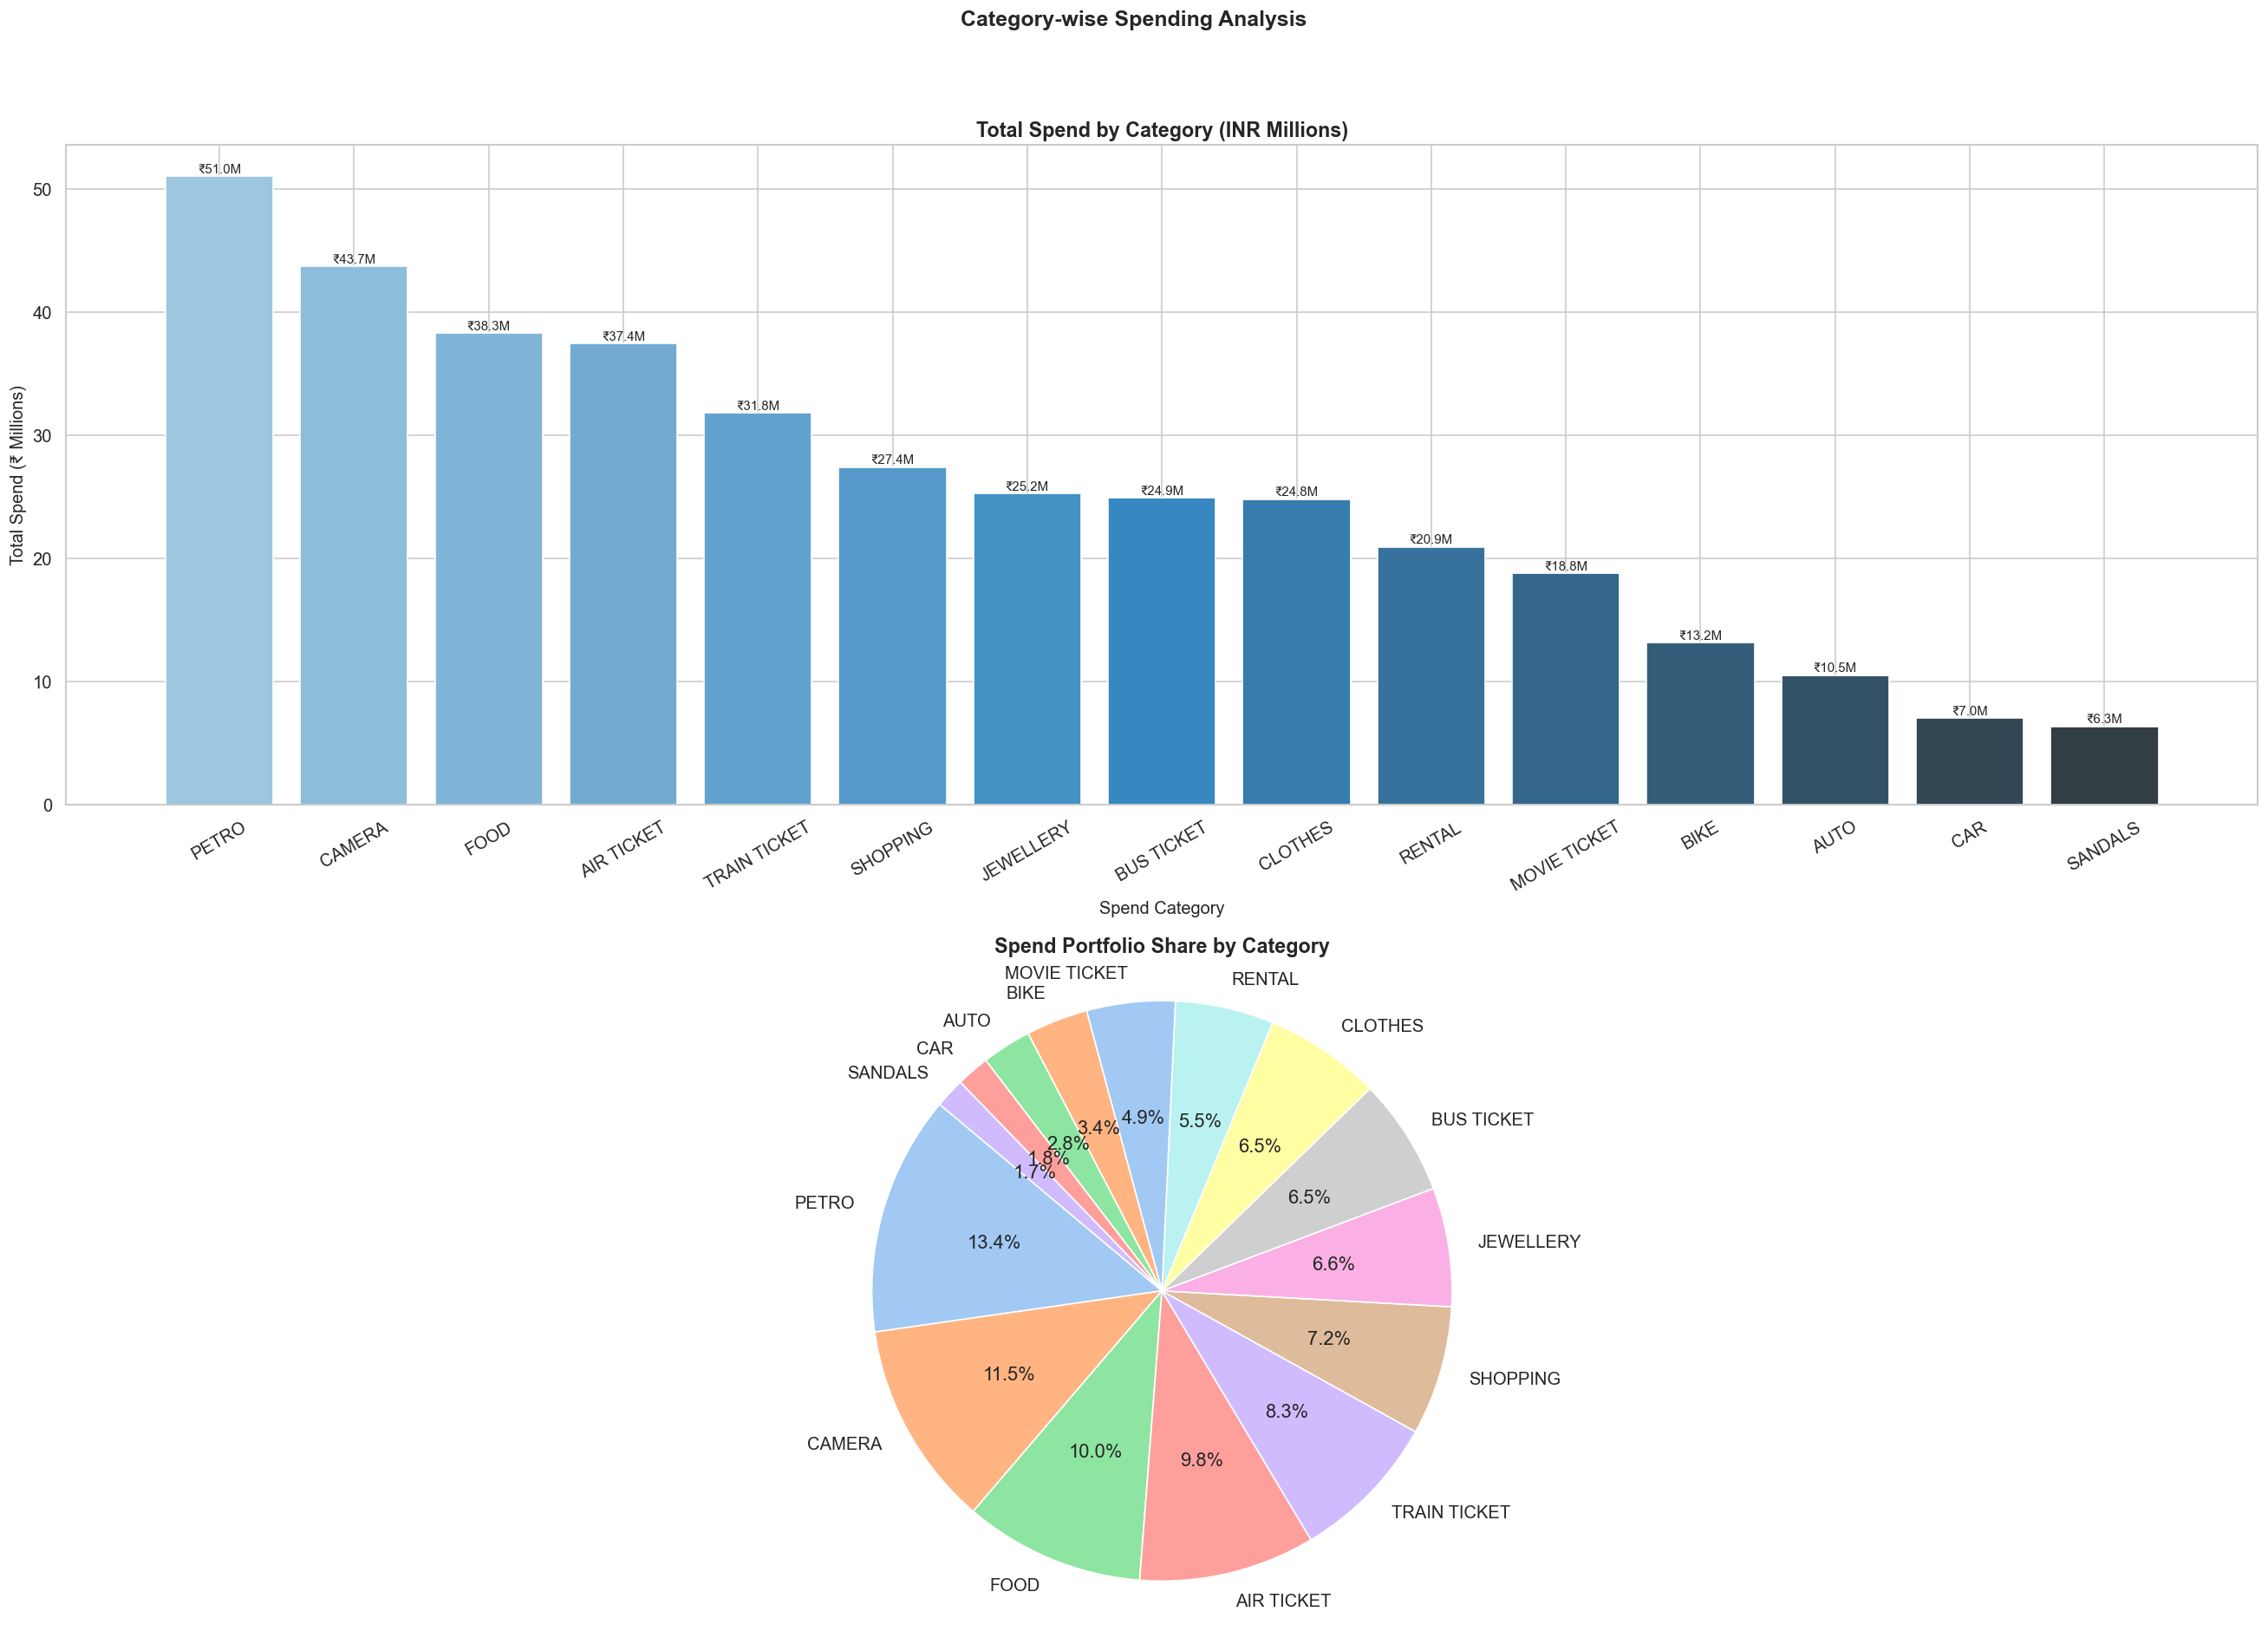

In [70]:
fig, axes = plt.subplots(2, 1, figsize=(22, 16))
# Bar chart — absolute spend by category
bars = axes[0].bar(
    category_spend['Type'],
    category_spend['Total_Spend'] / 1e6,
    color=sns.color_palette('Blues_d', len(category_spend))
)
axes[0].set_title('Total Spend by Category (INR Millions)')
axes[0].set_xlabel('Spend Category')
axes[0].set_ylabel('Total Spend (₹ Millions)')
axes[0].tick_params(axis='x', rotation=30)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'₹{bar.get_height():.1f}M', ha='center', va='bottom', fontsize=9)

# Pie chart — portfolio share
axes[1].pie(
    category_spend['Total_Spend'],
    labels=category_spend['Type'],
    autopct='%1.1f%%',
    radius = 1.1,
    startangle=140,
    colors=sns.color_palette('pastel')
)
axes[1].set_title('Spend Portfolio Share by Category')

plt.suptitle(
    'Category-wise Spending Analysis',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])  
plt.show()

**Business Insight for Spend Category Analysis:**  
The analysis of spending categories shows that some areas, such as Fuel, Food, and Travel, have the highest spending. These categories are great opportunities for banks to introduce co-branded reward programs (for example, partnerships with fuel stations, restaurants, or airlines). Such programs can encourage customers to use their cards more often, increasing customer loyalty and generating more revenue for the bank.

On the other hand, categories with lower spending may indicate that customers are not using their cards much in these areas. This presents an opportunity for banks to introduce targeted offers and discounts to encourage more spending and increase customer engagement.


### 6.2 Monthly Spending & Repayment Trends

Trend analysis over month


In [72]:
# Monthly aggregation of spend and repayment and finding coverage gap telling difference in spending and repayment in particular month.
monthly_spend = (
    spend.groupby('Month')['Amount'].sum().reset_index()
    .rename(columns={'Amount': 'Monthly_Spend'})
)
monthly_repayment = (
    repayment.assign(Month=pd.to_datetime(repayment['Date']).dt.to_period('M'))
    .groupby('Month')['Amount'].sum().reset_index()
    .rename(columns={'Amount': 'Monthly_Repayment'})
)
monthly = monthly_spend.merge(monthly_repayment, on='Month', how='outer').fillna(0)
monthly['Coverage_Gap'] = monthly['Monthly_Spend'] - monthly['Monthly_Repayment']
monthly['Month_dt'] = monthly['Month'].dt.to_timestamp()
monthly.head()

,Month,Monthly_Spend,Monthly_Repayment,Coverage_Gap,Month_dt
0,2004-01,75198633,"67,759,965.67","7,438,667.33",2004-01-01
1,2004-02,7306151,"5,472,305.34","1,833,845.66",2004-02-01
2,2004-03,3964728,"4,332,168.54","-367,440.54",2004-03-01
3,2004-04,6655481,"6,710,379.29","-54,898.29",2004-04-01
4,2004-05,4170904,"5,522,078.52","-1,351,174.52",2004-05-01


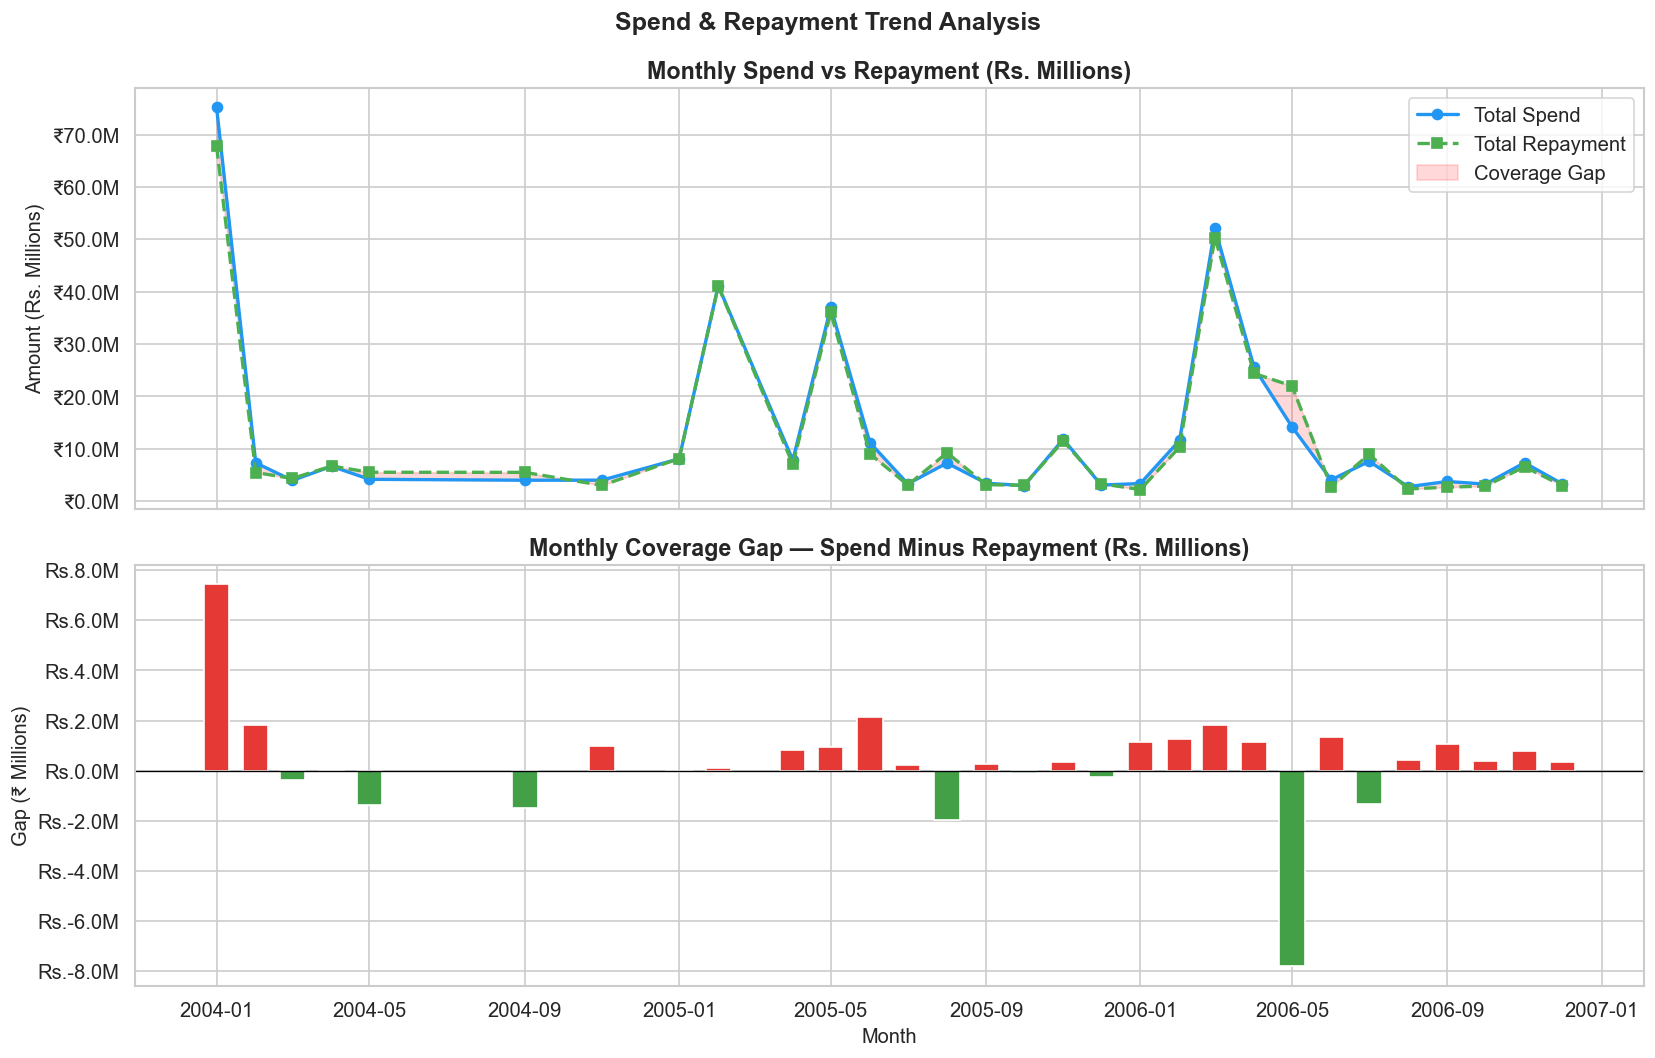

In [73]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Spend vs Repayment trend 
ax1.plot(monthly['Month_dt'], monthly['Monthly_Spend']/1e6,
         marker='o', linewidth=2, color='#2196F3', label='Total Spend')
ax1.plot(monthly['Month_dt'], monthly['Monthly_Repayment']/1e6,
         marker='s', linewidth=2, color='#4CAF50', linestyle='--', label='Total Repayment')
ax1.fill_between(monthly['Month_dt'],
                 monthly['Monthly_Spend']/1e6,
                 monthly['Monthly_Repayment']/1e6,
                 alpha=0.15, color='red', label='Coverage Gap')
ax1.set_title('Monthly Spend vs Repayment (Rs. Millions)')
ax1.set_ylabel('Amount (Rs. Millions)')
ax1.legend()
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('₹%.1fM'))

# Coverage Gap (revenue-at-risk)
colors = ['#e53935' if v > 0 else '#43a047' for v in monthly['Coverage_Gap']]
ax2.bar(monthly['Month_dt'], monthly['Coverage_Gap']/1e6, color=colors, width=20)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Monthly Coverage Gap — Spend Minus Repayment (Rs. Millions)')
ax2.set_ylabel('Gap (₹ Millions)')
ax2.set_xlabel('Month')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('Rs.%.1fM'))

plt.suptitle('Spend & Repayment Trend Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Business Insight for Monthly Trends:**  
The **Coverage Gap** (red shaded area) represents the bank's month-on-month **revenue at risk** which is
the portion of spending that has not yet been recovered. Persistent or widening gaps across consecutive
months are an early warning signal .This helps identify overall credit risk in the portfolio, allowing banks to take early actions such as improving collections or reviewing credit limits.


### 6.3 Demographic & Age-Based Spend Analysis

Age-segmented analysis helps the bank target products to the right life-stage cohorts.


In [78]:
# Create age bands which are standard banking cohorts
bins   = [17, 25, 35, 45, 55, 100]
labels = ['18–25', '26–35', '36–45', '46–55', '55+']
profile['Age_Band'] = pd.cut(profile['Age'], bins=bins, labels=labels)

age_analysis = (
    profile.groupby('Age_Band', observed=True)
    .agg(
        Customers     = ('Customer', 'count'),
        Avg_Spend     = ('Total_Spend', 'mean'),
        Avg_Limit     = ('Limit', 'mean'),
        Avg_Repayment = ('Total_Repayment', 'mean'),
        Avg_Utilisation = ('Utilisation_Ratio', 'mean')
    )
    .reset_index()
)
age_analysis

,Age_Band,Customers,Avg_Spend,Avg_Limit,Avg_Repayment,Avg_Utilisation
0,18–25,8,"2,505,632.88","227,501.00","2,101,091.74",3.83
1,26–35,12,"2,223,217.17","259,167.50","2,055,161.90",-3.12
2,36–45,12,"3,654,537.00","285,000.25","3,680,576.78",9.98
3,46–55,35,"4,007,423.89","290,286.31","3,764,925.48",5.40
4,55+,33,"4,561,033.21","301,818.76","4,660,559.22",-9.13


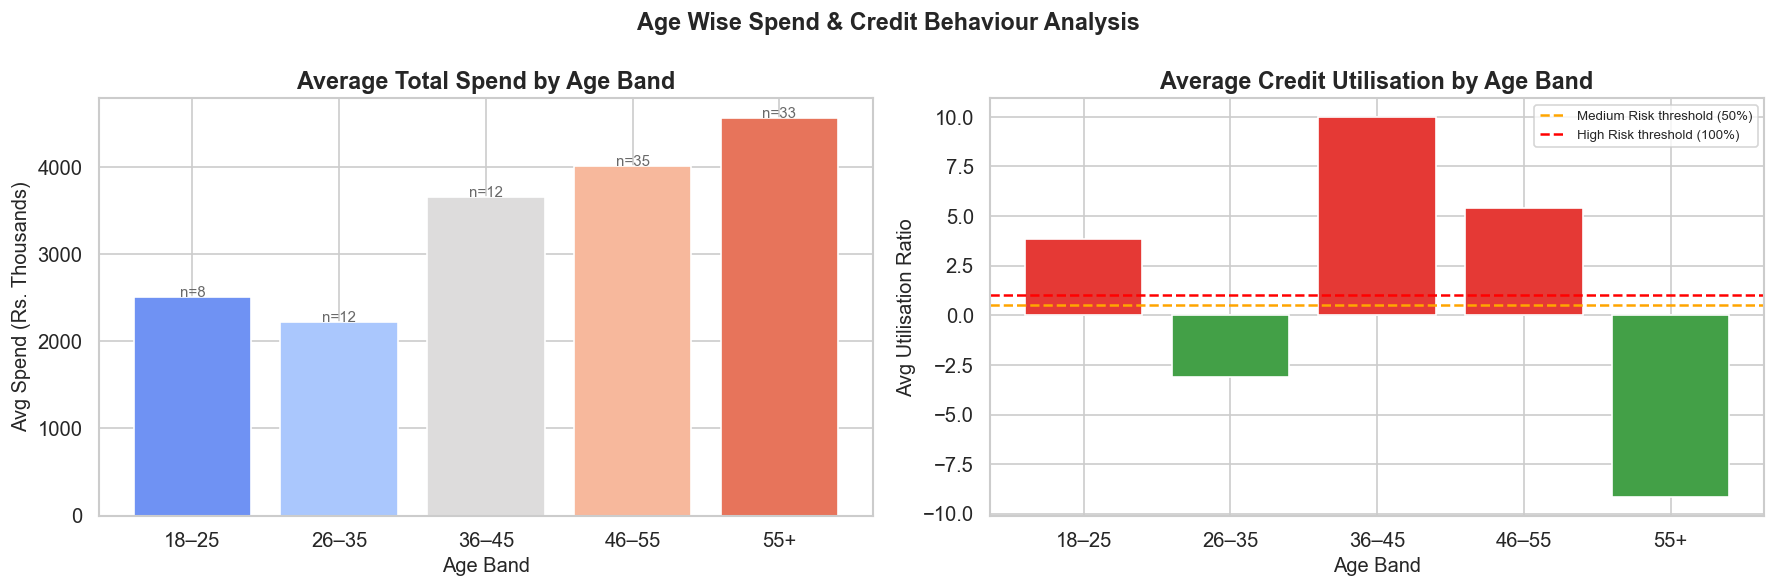

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

palette = sns.color_palette('coolwarm', len(age_analysis))

# Average spend by age band
axes[0].bar(age_analysis['Age_Band'].astype(str), age_analysis['Avg_Spend']/1e3,
            color=palette)
axes[0].set_title('Average Total Spend by Age Band')
axes[0].set_xlabel('Age Band')
axes[0].set_ylabel('Avg Spend (Rs. Thousands)')
for i, row in age_analysis.iterrows():
    axes[0].text(i, row['Avg_Spend']/1e3 + 5, f'n={row["Customers"]}',
                 ha='center', fontsize=9, color='dimgrey')

# Average utilisation by age band
util_colors = ['#e53935' if x > 0.5 else '#43a047' for x in age_analysis['Avg_Utilisation']]
axes[1].bar(age_analysis['Age_Band'].astype(str), age_analysis['Avg_Utilisation'],
            color=util_colors)
axes[1].axhline(0.5,  color='orange', linewidth=1.5, linestyle='--', label='Medium Risk threshold (50%)')
axes[1].axhline(1.0,  color='red',    linewidth=1.5, linestyle='--', label='High Risk threshold (100%)')
axes[1].set_title('Average Credit Utilisation by Age Band')
axes[1].set_xlabel('Age Band')
axes[1].set_ylabel('Avg Utilisation Ratio')
axes[1].legend(fontsize=8)

plt.suptitle('Age Wise Spend & Credit Behaviour Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Business Insight for Age wise analysis:**  
The **26–35 age age band** typically drives the highest absolute spend, making it the bank's **primary
growth segment** for premium products. Conversely, if older age bands show higher utilisation ratios,
they may warrant tighter credit controls. This data directly informs age-targeted marketing budgets
and product design (e.g., lifestyle vs. savings-oriented card benefits).<br>
<br>
- **Red**
    - Represents: High credit utilisation.
    - Condition: Avg_Utilisation > 0.5 (more than 50% of the credit limit).
    - Business Interpretation:
    - Customers are using a large portion of their available credit.
    - Indicates higher financial risk.
    - May require closer monitoring, credit limit reviews, or risk controls.<br>
- **Green**
    - Represents: Healthy or manageable credit utilisation.
    - Condition: Avg_Utilisation ≤ 0.5 (50% or less).
    - Business Interpretation:
    - Customers are using credit responsibly.Indicates lower risk.
    - These customers may be good candidates for credit limit increases or premium offers.

### 6.4 Credit Utilisation Distribution

High-risk customers (utilisation > 100%): 33.0%
Overpaid customers   (net balance < 0)  : 45.0%


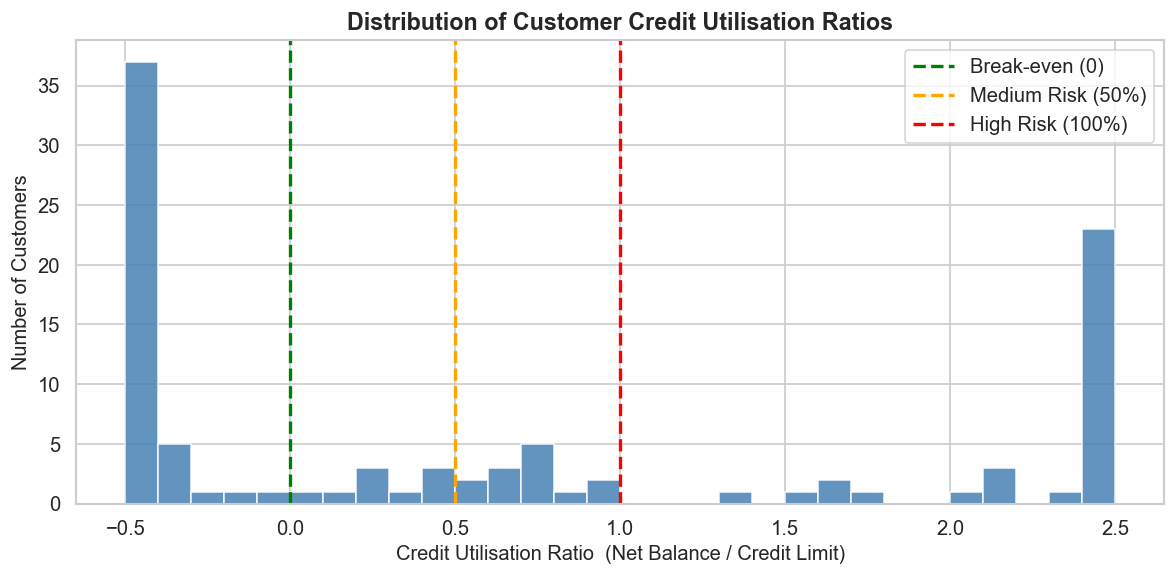

In [79]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(profile['Utilisation_Ratio'].clip(-0.5, 2.5), bins=30,
        color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0,   color='green',  linewidth=2, linestyle='--', label='Break-even (0)')
ax.axvline(0.5, color='orange', linewidth=2, linestyle='--', label='Medium Risk (50%)')
ax.axvline(1.0, color='red',    linewidth=2, linestyle='--', label='High Risk (100%)')
ax.set_title('Distribution of Customer Credit Utilisation Ratios')
ax.set_xlabel('Credit Utilisation Ratio  (Net Balance / Credit Limit)')
ax.set_ylabel('Number of Customers')
ax.legend()

pct_high = (profile['Utilisation_Ratio'] > 1.0).mean() * 100
pct_over = (profile['Utilisation_Ratio'] < 0).mean() * 100
print(f'High-risk customers (utilisation > 100%): {pct_high:.1f}%')
print(f'Overpaid customers   (net balance < 0)  : {pct_over:.1f}%')

plt.tight_layout()
plt.show()

---
## 7. Risk Analysis

Risk classification allows the bank to **segment its portfolio** into action groups:
collections teams focus on High-Risk customers; product teams grow the Low-Risk base.


### 7.1 Risk Flag Engineering

In [80]:
def assign_risk_category(utilisation_ratio):
    """
    Classify a customer's credit risk based on utilisation ratio:
    > 1.00  →  High Risk    : balance exceeds credit limit (over-limit)
    > 0.50  →  Medium Risk  : more than half the limit utilised
    >= 0    →  Low Risk     : utilisation within acceptable range
    < 0     →  Overpaid     : repayments exceed spending — no outstanding
    """
    if pd.isna(utilisation_ratio):
        return 'Unknown'
    if utilisation_ratio > 1.0:
        return 'High Risk'
    elif utilisation_ratio > 0.5:
        return 'Medium Risk'
    elif utilisation_ratio >= 0:
        return 'Low Risk'
    else:
        return 'Overpaid'

profile['Risk_Category'] = profile['Utilisation_Ratio'].apply(assign_risk_category)

risk_order = ['High Risk', 'Medium Risk', 'Low Risk', 'Overpaid']
risk_counts = profile['Risk_Category'].value_counts().reindex(risk_order)

print('Portfolio Risk Breakdown:')
for cat, cnt in risk_counts.items():
    print(f'  {cat:<15}: {cnt:>3} customers ({cnt/len(profile)*100:.1f}%)')

Portfolio Risk Breakdown:
  High Risk      :  33 customers (33.0%)
  Medium Risk    :  13 customers (13.0%)
  Low Risk       :   9 customers (9.0%)
  Overpaid       :  45 customers (45.0%)


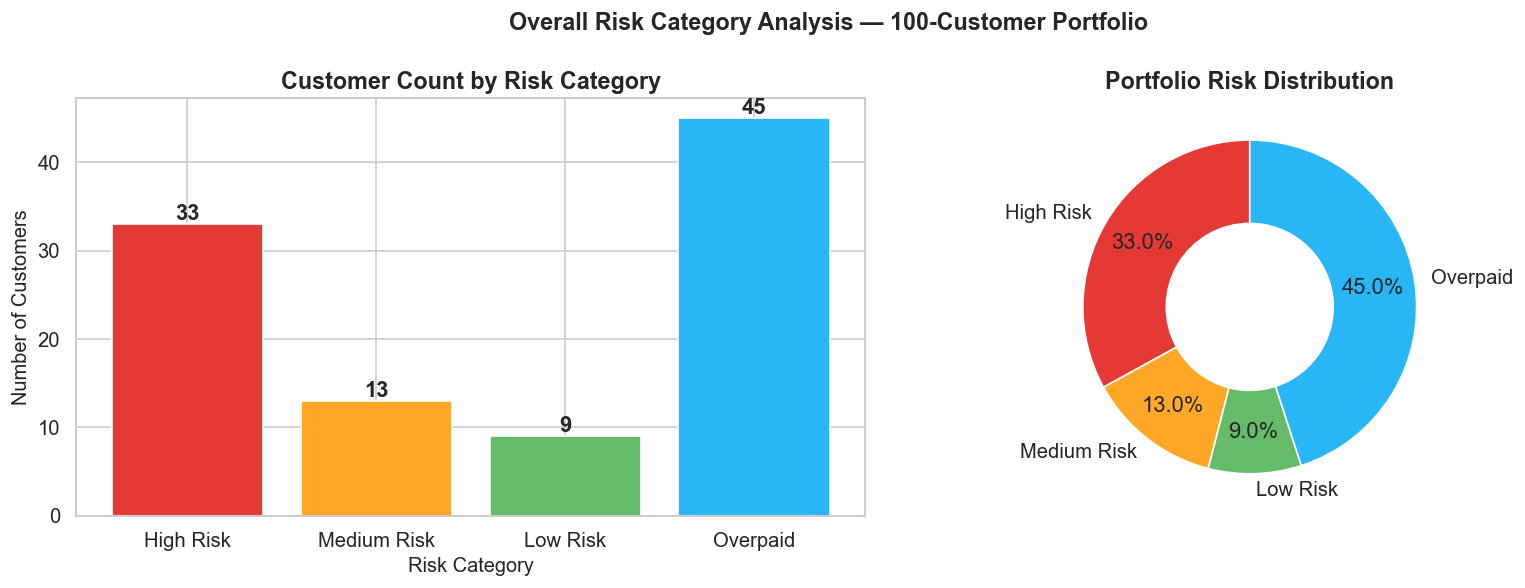

In [81]:
RISK_COLORS = {
    'High Risk'   : '#e53935',
    'Medium Risk' : '#FFA726',
    'Low Risk'    : '#66BB6A',
    'Overpaid'    : '#29B6F6',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bar_colors = [RISK_COLORS[c] for c in risk_counts.index]
axes[0].bar(risk_counts.index, risk_counts.values, color=bar_colors, edgecolor='white')
for i, (cat, val) in enumerate(risk_counts.items()):
    axes[0].text(i, val + 0.5, str(val), ha='center', fontweight='bold')
axes[0].set_title('Customer Count by Risk Category')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xlabel('Risk Category')

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    risk_counts.values,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    colors=bar_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'width': 0.5}
)
axes[1].set_title('Portfolio Risk Distribution')

plt.suptitle('Overall Risk Category Analysis — 100-Customer Portfolio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 Risk Profile by Customer Segment

Segment-level risk reveals which customer groups require immediate policy intervention.


In [82]:
risk_by_segment = (
    profile.groupby(['Segment', 'Risk_Category'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=risk_order, fill_value=0)
)

risk_seg_pct = risk_by_segment.div(risk_by_segment.sum(axis=1), axis=0) * 100
print('Risk % by Segment:')
print(risk_seg_pct.round(1))

Risk % by Segment:
Risk_Category  High Risk  Medium Risk  Low Risk  Overpaid
Segment                                                  
Govt               20.70        17.20     13.80     48.30
Normal Salary      40.90         4.50      0.00     54.50
Salaried_MNC       15.40        23.10      7.70     53.80
Salaried_Pvt       53.80        23.10      7.70     15.40
Self Employed      39.10         4.30     13.00     43.50


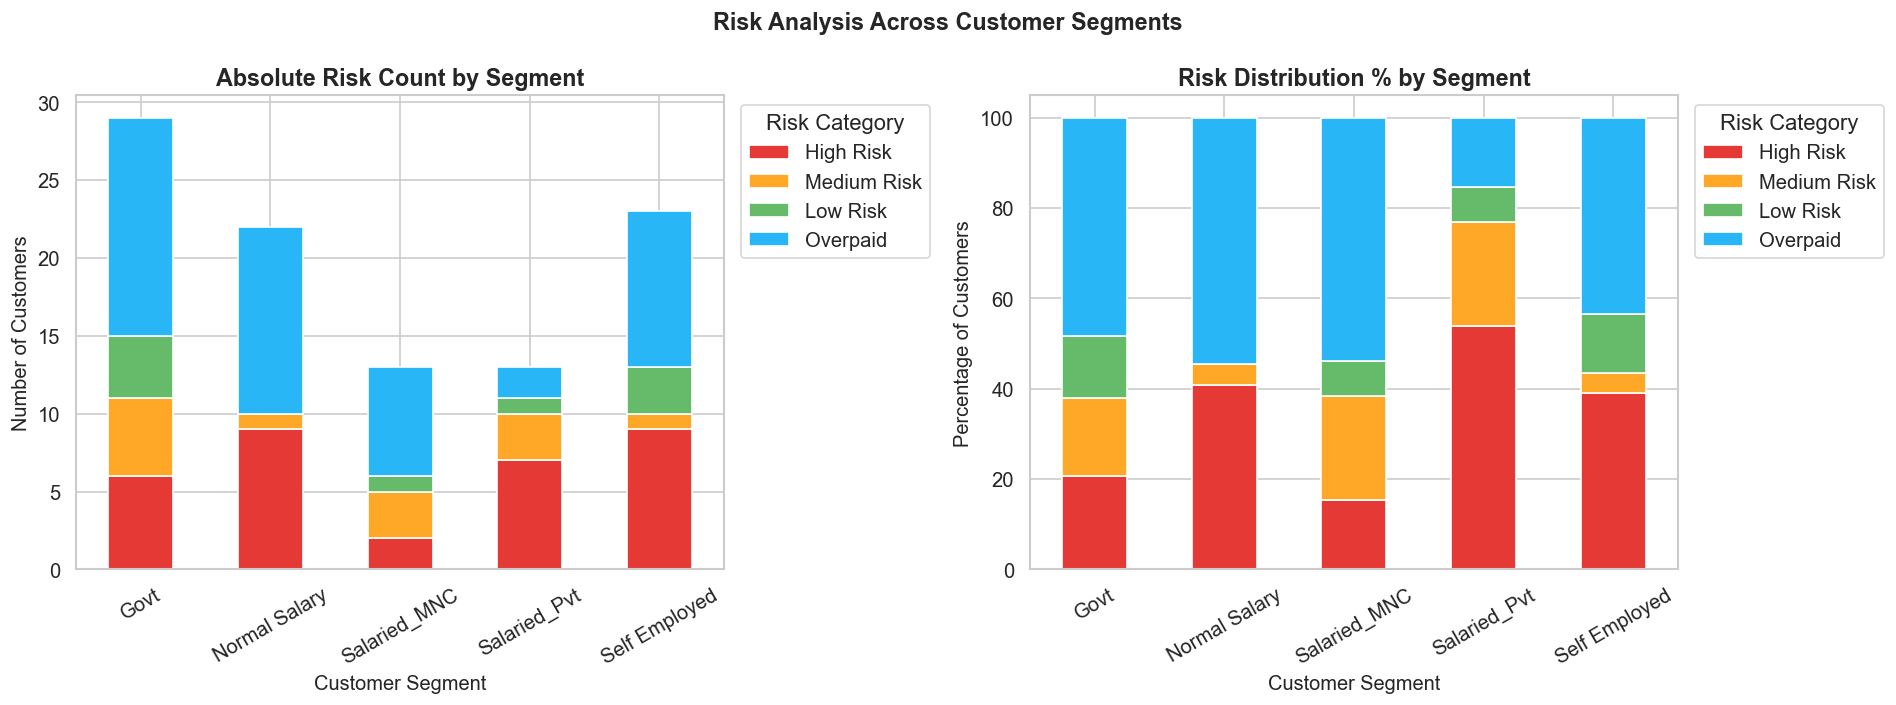

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

seg_colors = [RISK_COLORS[c] for c in risk_by_segment.columns]

risk_by_segment.plot(kind='bar', stacked=True, ax=axes[0],
                      color=seg_colors, edgecolor='white')
axes[0].set_title('Absolute Risk Count by Segment')
axes[0].set_xlabel('Customer Segment')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Risk Category', bbox_to_anchor=(1.01, 1))

risk_seg_pct.plot(kind='bar', stacked=True, ax=axes[1],
                  color=seg_colors, edgecolor='white')
axes[1].set_title('Risk Distribution % by Segment')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Percentage of Customers')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Risk Category', bbox_to_anchor=(1.01, 1))

plt.suptitle('Risk Analysis Across Customer Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Business Insight for Risk by Segment:**  
The **Salaried Private sector** has the highest number of high-risk customers, which may indicate financial stress due to unstable or variable income. To reduce risk, the bank can consider lower credit limits for new customers in this segment or introduce income-based credit products.

On the other hand, segments with a high number of overpaid customers (those who pay more than their outstanding balance) show responsible financial behavior. These customers are suitable candidates for credit limit increases and premium credit card offers.


### 7.3 Risk Profile by Credit Card Product

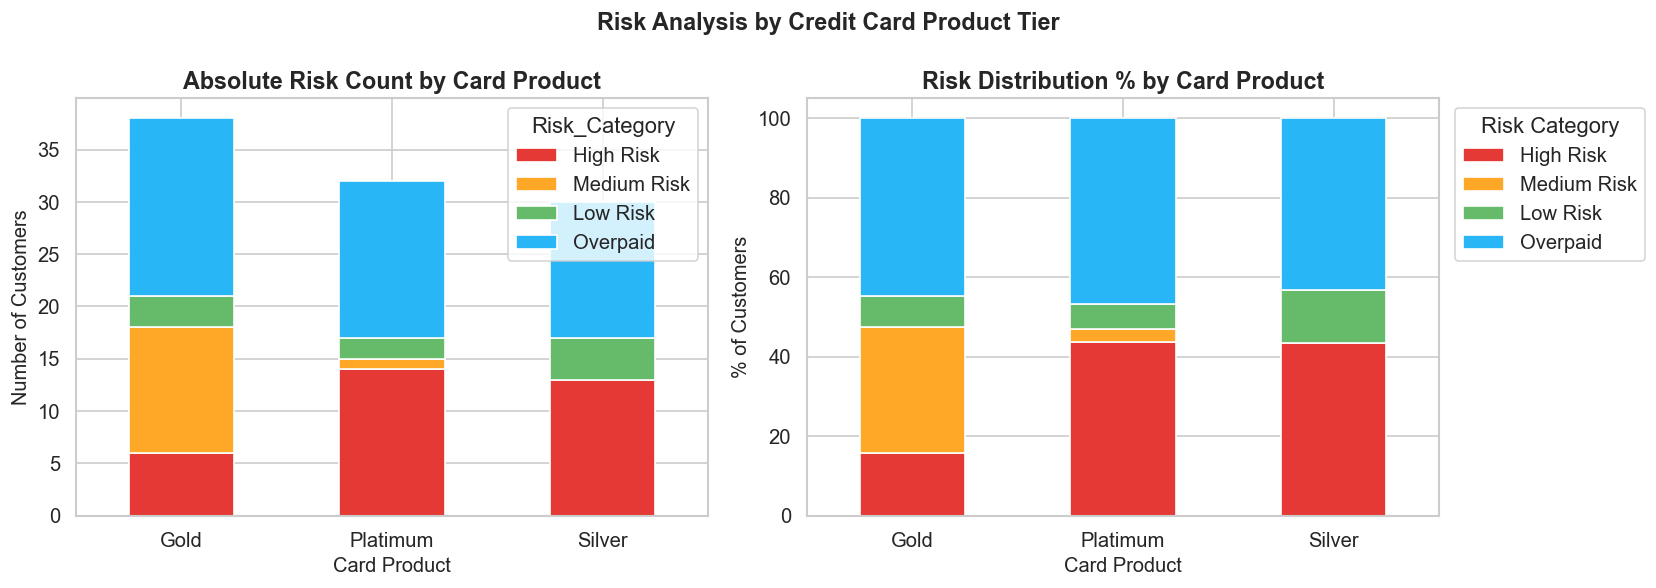

In [84]:
risk_by_product = (
    profile.groupby(['Credit Card Product', 'Risk_Category'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=risk_order, fill_value=0)
)

risk_prod_pct = risk_by_product.div(risk_by_product.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
prod_colors = [RISK_COLORS[c] for c in risk_by_product.columns]

risk_by_product.plot(kind='bar', stacked=True, ax=axes[0],
                      color=prod_colors, edgecolor='white')
axes[0].set_title('Absolute Risk Count by Card Product')
axes[0].set_xlabel('Card Product')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)

risk_prod_pct.plot(kind='bar', stacked=True, ax=axes[1],
                   color=prod_colors, edgecolor='white')
axes[1].set_title('Risk Distribution % by Card Product')
axes[1].set_xlabel('Card Product')
axes[1].set_ylabel('% of Customers')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Risk Category', bbox_to_anchor=(1.01, 1))

plt.suptitle('Risk Analysis by Credit Card Product Tier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Business Insight for Risk by Product:**  
**Platinum and Silver card** holders show a higher number of high-risk customers. This may indicate a credit limit mismatch, meaning the bank has provided high credit limits to some customers who may not have the capacity to repay their dues.

In contrast, **Gold card** holders demonstrate a healthier risk profile, suggesting that this mid-tier card attracts more financially stable customers. Therefore, Gold card users are an ideal segment for loyalty programs and retention initiatives.


---
## 8. Correlation & Portfolio Health

Correlation analysis surfaces hidden relationships between financial variables which are essential for
building future risk models.


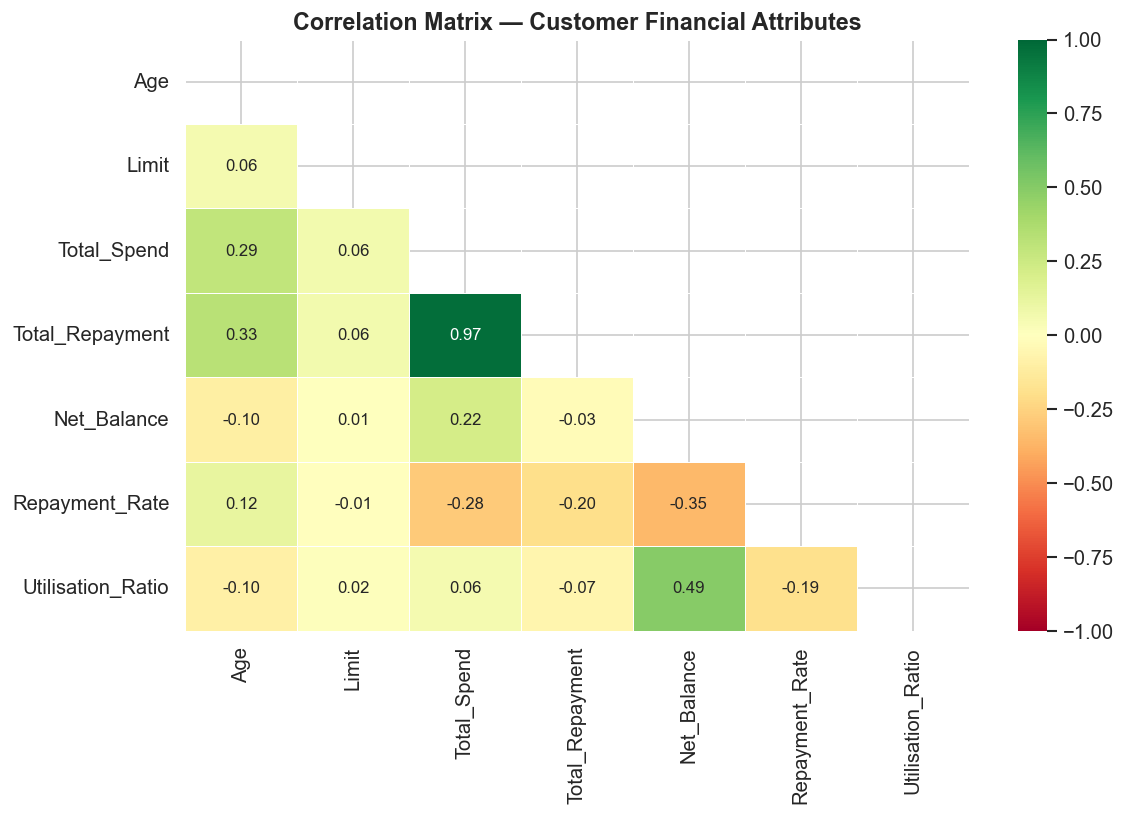

In [86]:
# Numeric features relevant to the bank's risk assessment
numeric_cols = ['Age', 'Limit', 'Total_Spend', 'Total_Repayment',
                'Net_Balance', 'Repayment_Rate', 'Utilisation_Ratio']
corr_matrix = profile[numeric_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    mask=mask,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 10}
)
plt.title('Correlation Matrix — Customer Financial Attributes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

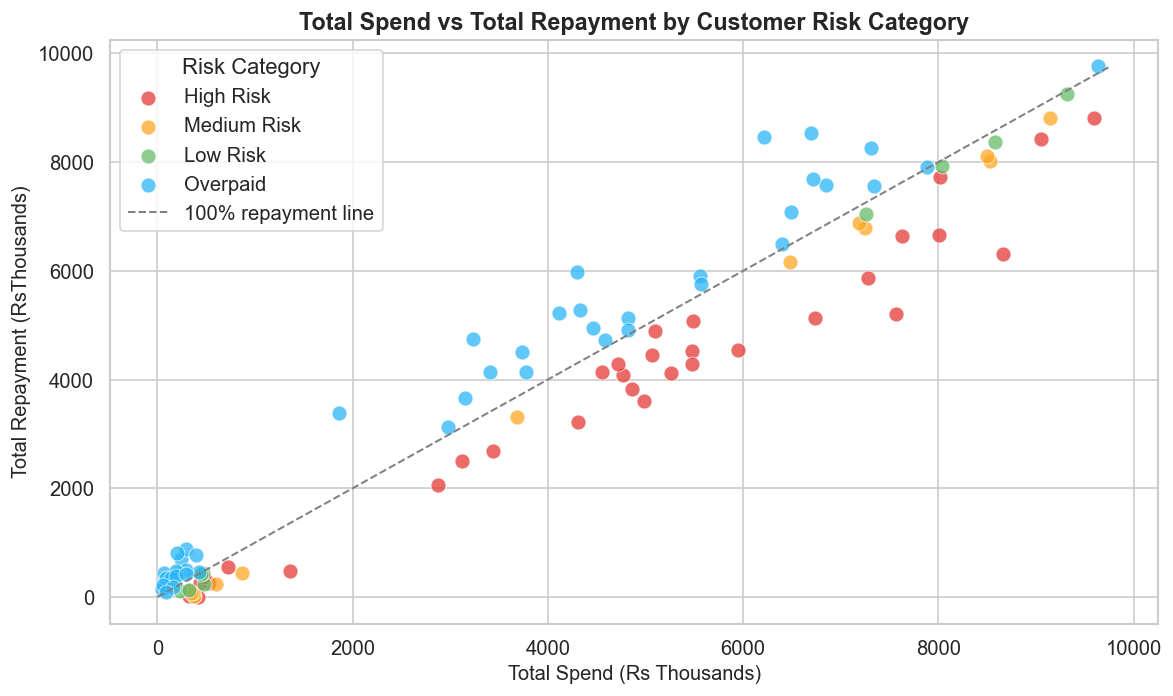

In [87]:
# Spend vs Repayment scatter — coloured by risk 
fig, ax = plt.subplots(figsize=(10, 6))

for risk_cat in risk_order:
    subset = profile[profile['Risk_Category'] == risk_cat]
    ax.scatter(
        subset['Total_Spend']/1e3,
        subset['Total_Repayment']/1e3,
        label=risk_cat,
        color=RISK_COLORS[risk_cat],
        alpha=0.75, s=80, edgecolors='white', linewidths=0.5
    )

# Perfect repayment reference line
lims = [0, max(profile['Total_Spend'].max(), profile['Total_Repayment'].max()) / 1e3]
ax.plot(lims, lims, '--', color='grey', linewidth=1.2, label='100% repayment line')

ax.set_title('Total Spend vs Total Repayment by Customer Risk Category')
ax.set_xlabel('Total Spend (Rs Thousands)')
ax.set_ylabel('Total Repayment (RsThousands)')
ax.legend(title='Risk Category')
plt.tight_layout()
plt.show()

**Business Insight — Correlation Analysis:**  
The scatter plot clearly separates customer risk tiers. Customers **above the diagonal** are
overpaid which are valuable for upsell. Customers **far below the diagonal** are high-risk and are priority
for collections intervention. A strong positive correlation between Total_Spend and Limit shows that customers with higher credit limits tend to spend more. However, these customers also need closer monitoring, because any limit breaches can significantly increase the bank’s provisioning risk.

---
## 9. Key Business Insights

| # | Finding | Business Implication |
|---|---|---|
| 1 | **~45% of customers are Overpaid** — repayments exceed spending |These customers manage their credit well. The bank can offer them higher credit limits and upgrade them to premium cards.|
| 2 | **Salaried Private sector has highest High-Risk concentration (~54%)** | This segment needs careful screening. The bank should verify income more strictly before approving credit.|
| 3 | **Platinum & Silver cards show highest risk (~43% High Risk)** | Some customers may have received high-limit cards without sufficient repayment capacity. The bank should review approval criteria for these cards.|
| 4 | **Gold card users have the lowest High-Risk rate (~16%)** | Gold card customers are financially stable. The bank should focus on loyalty rewards to retain them. |
| 5 | **26–35 age cohort drives the highest spend volumes** | This age group is a key growth segment. The bank should target them with rewards, EMI options, and lifestyle-related offers. |
| 6 | **Persistent monthly Coverage Gaps indicate structural repayment lag** | Customers may be slow in repaying their dues. Sending reminders before the due date can help improve repayment behavior. |
| 7 | **Spend concentrated in 2–3 categories** | The bank can partner with merchants in these top categories and offer category-specific cashback or discounts.|


10. **Business Recommendations**
- **Immediate Actions** (Risk Mitigation)
1. Auto-flag and freeze over-limit accounts to prevent additional spending until a partial repayment is made.
2. Prioritize collections for High-Risk customers, especially within the Salaried Private segment.
3. Reduce credit limits during the next review for customers with a Utilisation Ratio > 1.0.
- **Medium-Term Actions** 
1.  Strengthen underwriting for Platinum and Silver card applicants by requiring higher income verification.
2. Encourage early repayments by offering incentives such as 1% cashback for customers who pay their full outstanding balance before the due date.
3. Implement monthly trend alerts to automatically trigger an account review if a customer’s repayment-spend gap widens for two or more consecutive months.
- **Growth Actions** 
1. Upsell credit limit enhancements to Overpaid customers, as they demonstrate strong repayment capacity.
2. Establish co-brand partnerships in the top 2–3 spending categories to increase interchange revenue.
3. Launch lifecycle marketing campaigns targeting the 26–35 age cohort, the highest spending segment with significant growth potential.


---
## 11. Conclusion

This analysis converted raw transactional data from three banking tables into a structured customer risk intelligence framework. Key findings include:

- Portfolio Health: Around 45% of customers demonstrate net-positive repayment behaviour, indicating a generally stable portfolio. However, a High-Risk segment (~20–25%) requires focused monitoring and intervention.
- Segment Vulnerability: The Salaried Private sector shows signs of higher financial stress and over-leverage, suggesting a mismatch between assigned credit limits and repayment capacity.
- Product Risk Concentration: Premium card tiers (Platinum and Silver) exhibit higher risk exposure per customer, highlighting the need to re-evaluate eligibility and credit assignment rules.
- Growth Opportunity: Gold card customers aged 26–45 form the most stable and high-value segment, making them key targets for retention, engagement, and controlled credit expansion.

>While this analysis is based on a 100-customer sample, scaling it to a full banking portfolio could significantly improve risk control, reduce non-performing assets, and unlock revenue through targeted credit optimisation and customer segmentation strategies.